# Portfolio 2 — NHANES Dietary Predictors of Glycaemic Status
## Notebook 03: Regression Analysis

**Research question:** Do dietary patterns predict glycaemic outcomes (HbA1c, fasting glucose)
after adjusting for BMI, age and sex?

**Three models:**
1. **Linear regression** — HbA1c as a continuous outcome (how much does each predictor move HbA1c?)
2. **Logistic regression** — prediabetes/diabetes (binary) as outcome (what are the odds?)
3. **Sensitivity analysis** — same models stratified by BMI group (does the dietary signal differ by adiposity?)

All continuous predictors are standardised (z-scores) so coefficients are directly comparable.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from sklearn.preprocessing import StandardScaler

## Step 1: Load clean dataset

In [2]:
df = pd.read_csv('/Users/larascofano/Documents/Obsidian Vault/career/Portfolio 2/data/nhanes_clean.csv')
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

Shape: (2517, 19)
Columns: ['SEQN', 'age', 'sex', 'race', 'income', 'survey_weight', 'is_pregnant', 'fasting glucose (mg/DL)', 'carb_avg', 'sugar_avg', 'fiber_avg', 'fat_avg', 'kcal_avg', 'HbA1c (%)', 'vigorous activity', 'moderate activity', 'BMI', 'waist circumference', 'diabetic_status']


## Step 2: Prepare variables for modelling

**a)** Binary outcome: 0 = normal HbA1c (< 5.7%), 1 = prediabetic or diabetic (≥ 5.7%)

**b)** Standardise continuous predictors so all coefficients are in SD units (directly comparable)

**c)** Categorical: sex is already binary; age kept continuous


In [3]:
# a) Binary outcome
df['diabetic_binary'] = (df['diabetic_status'] != 'normal').astype(int)
print("diabetic_binary distribution:")
print(df['diabetic_binary'].value_counts())

# b) Standardise
cols_to_scale = ['carb_avg', 'sugar_avg', 'fiber_avg', 'fat_avg', 'kcal_avg', 'BMI']
scaler = StandardScaler()
scaled_values = scaler.fit_transform(df[cols_to_scale])
scaled_df = pd.DataFrame(scaled_values, columns=[c + '_z' for c in cols_to_scale], index=df.index)
df = pd.concat([df, scaled_df], axis=1)

print()
print("Standardised columns added:")
print(df[['carb_avg', 'carb_avg_z']].describe().round(3))

diabetic_binary distribution:
0    1386
1    1131
Name: diabetic_binary, dtype: int64

Standardised columns added:
       carb_avg  carb_avg_z
count  2293.000    2293.000
mean    238.717       0.000
std     110.443       1.000
min       1.000      -2.153
25%     166.660      -0.653
50%     224.230      -0.131
75%     294.840       0.508
max    1063.070       7.466


## Step 3: Linear Regression — HbA1c as continuous outcome

**What to look at in the output:**
- `coef`: direction and magnitude of effect (in SD units)
- `P>|t|`: is it statistically significant? (< 0.05)
- `[0.025, 0.975]`: confidence interval — does it cross zero?
- **R²**: how much variance in HbA1c does the model explain overall?


In [4]:
formula_linear = 'Q("HbA1c (%)") ~ carb_avg_z + sugar_avg_z + fiber_avg_z + fat_avg_z + BMI_z + age + C(sex)'
model = smf.ols(formula=formula_linear, data=df).fit()
print(model.summary())
print(f"R² = {model.rsquared:.3f}")

                            OLS Regression Results                            
Dep. Variable:         Q("HbA1c (%)")   R-squared:                       0.147
Model:                            OLS   Adj. R-squared:                  0.145
Method:                 Least Squares   F-statistic:                     55.66
Date:                Sun, 01 Mar 2026   Prob (F-statistic):           9.97e-74
Time:                        20:22:12   Log-Likelihood:                -3244.4
No. Observations:                2261   AIC:                             6505.
Df Residuals:                    2253   BIC:                             6551.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         5.0160      0.069     72.739

## Step 4: Coefficient Plot — Linear Regression

Visualise effect sizes and confidence intervals at a glance.
- Points to the right of x=0 → positive association with HbA1c
- Points to the left → protective / inverse association
- CIs crossing x=0 → not statistically significant


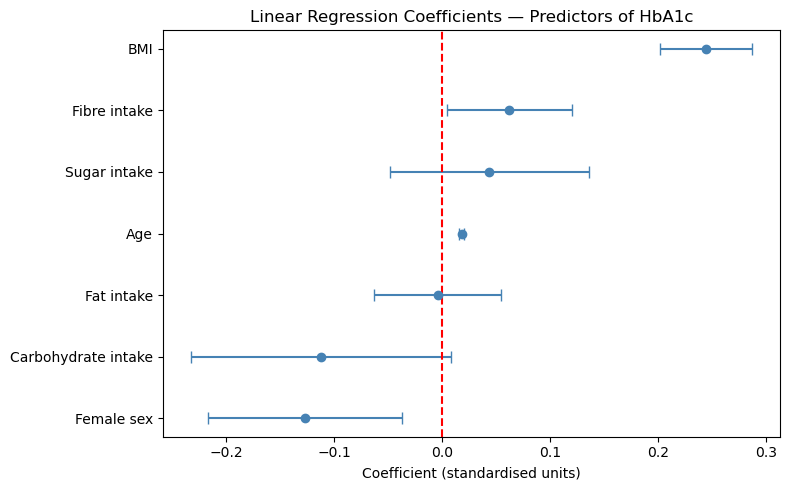

Saved: 03_linear_regression.png


In [5]:
# Extract coefficients and 95% CIs
coef_df = pd.DataFrame({
    'coef':    model.params,
    'ci_low':  model.conf_int()[0],
    'ci_high': model.conf_int()[1]
}).drop('Intercept')

coef_df = coef_df.sort_values('coef', ascending=True)

rename_map = {
    'carb_avg_z':    'Carbohydrate intake',
    'sugar_avg_z':   'Sugar intake',
    'fiber_avg_z':   'Fibre intake',
    'fat_avg_z':     'Fat intake',
    'BMI_z':         'BMI',
    'age':           'Age',
    'C(sex)[T.2.0]': 'Female sex'
}
coef_df = coef_df.rename(index=rename_map)

fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(
    x=coef_df['coef'],
    y=range(len(coef_df)),
    xerr=[coef_df['coef'] - coef_df['ci_low'], coef_df['ci_high'] - coef_df['coef']],
    fmt='o', color='steelblue', capsize=4
)
ax.axvline(x=0, color='r', linestyle='--')
ax.set_xlabel('Coefficient (standardised units)')
ax.set_yticks(range(len(coef_df)))
ax.set_yticklabels(coef_df.index)
ax.set_title('Linear Regression Coefficients — Predictors of HbA1c')
plt.tight_layout()
plt.savefig('/Users/larascofano/Documents/Obsidian Vault/career/Portfolio 2/figures/03_linear_regression.png')
plt.show()
print("Saved: 03_linear_regression.png")

## Step 5: Logistic Regression — odds of prediabetes/diabetes

**Binary outcome:** HbA1c ≥ 5.7% = prediabetic or diabetic (coded 1)

**Odds Ratios (OR):**
- OR > 1: variable *increases* odds of prediabetes/diabetes
- OR < 1: variable *decreases* odds (protective)
- CI crosses 1.0 → not statistically significant
- **Pseudo R² (McFadden):** rough goodness of fit — 0.1–0.3 = acceptable


In [6]:
formula_logit = 'diabetic_binary ~ carb_avg_z + sugar_avg_z + fiber_avg_z + fat_avg_z + BMI_z + age + C(sex)'
logit_model = smf.logit(formula=formula_logit, data=df).fit()
print(logit_model.summary())

# Compute Odds Ratios and CIs
OR = np.exp(logit_model.params)
CI = np.exp(logit_model.conf_int())
or_df = pd.DataFrame({'OR': OR, 'CI_low': CI[0], 'CI_high': CI[1]}).drop('Intercept')
print()
print("Odds Ratios (95% CI):")
print(or_df.round(3).to_string())

Optimization terminated successfully.
         Current function value: 0.556592
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:        diabetic_binary   No. Observations:                 2264
Model:                          Logit   Df Residuals:                     2256
Method:                           MLE   Df Model:                            7
Date:                Sun, 01 Mar 2026   Pseudo R-squ.:                  0.1882
Time:                        20:22:12   Log-Likelihood:                -1260.1
converged:                       True   LL-Null:                       -1552.2
Covariance Type:            nonrobust   LLR p-value:                6.457e-122
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        -3.1113      0.179    -17.430      0.000      -3.461      -2.761
C(sex)[T.2.0]    -0.

## Step 6: Forest Plot — Odds Ratios

Same structure as the coefficient plot but:
- x-axis shows ORs (multiplicative scale)
- Null line at x=1 (not x=0)
- OR > 1 = increases odds; OR < 1 = decreases odds


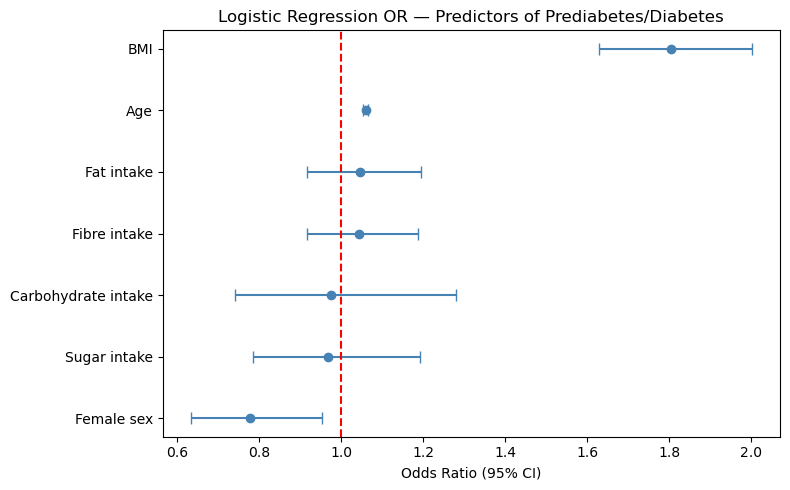

Saved: 03_logistic_regression.png


In [7]:
or_df = or_df.sort_values('OR', ascending=True)
or_df = or_df.rename(index=rename_map)

fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(
    x=or_df['OR'],
    y=range(len(or_df)),
    xerr=[or_df['OR'] - or_df['CI_low'], or_df['CI_high'] - or_df['OR']],
    fmt='o', color='steelblue', capsize=4
)
ax.axvline(x=1, color='r', linestyle='--')
ax.set_xlabel('Odds Ratio (95% CI)')
ax.set_yticks(range(len(or_df)))
ax.set_yticklabels(or_df.index)
ax.set_title('Logistic Regression OR — Predictors of Prediabetes/Diabetes')
plt.tight_layout()
plt.savefig('/Users/larascofano/Documents/Obsidian Vault/career/Portfolio 2/figures/03_logistic_regression.png')
plt.show()
print("Saved: 03_logistic_regression.png")

## Step 7: Sensitivity Analysis — Stratified by BMI Group

**Question:** Does the dietary signal differ between normal-weight and overweight participants?

This tests whether diet effects are confounded by adiposity.
If dietary ORs remain close to 1.0 *within* each BMI stratum, it confirms the overall null dietary finding.

| BMI group | Threshold |
|---|---|
| Normal weight | BMI < 25 |
| Overweight | 25 ≤ BMI < 30 |
| Obese | BMI ≥ 30 |


In [8]:
df['bmi_group'] = pd.cut(df['BMI'], bins=[0, 25, 30, 100],
                         labels=['normal weight', 'overweight', 'obese'])

results = {}
for group in ['normal weight', 'overweight', 'obese']:
    subset = df[df['bmi_group'] == group]
    model_strat = smf.logit(formula=formula_logit, data=subset).fit(disp=0)
    OR = np.exp(model_strat.params)
    CI = np.exp(model_strat.conf_int())
    or_df_strat = pd.DataFrame({'OR': OR, 'CI_low': CI[0], 'CI_high': CI[1]}).drop('Intercept')
    print(f'--- {group} (n={len(subset)}) ---')
    print(or_df_strat.round(3).to_string())
    print()
    results[group] = or_df_strat

# Rename for plot
for group in results:
    results[group] = results[group].rename(index=rename_map)

--- normal weight (n=696) ---
                  OR  CI_low  CI_high
C(sex)[T.2.0]  0.730   0.468    1.138
carb_avg_z     1.147   0.689    1.907
sugar_avg_z    0.786   0.523    1.182
fiber_avg_z    1.041   0.812    1.334
fat_avg_z      1.065   0.813    1.395
BMI_z          3.459   1.587    7.540
age            1.066   1.053    1.078

--- overweight (n=791) ---
                  OR  CI_low  CI_high
C(sex)[T.2.0]  0.760   0.540    1.071
carb_avg_z     0.827   0.520    1.314
sugar_avg_z    1.158   0.809    1.657
fiber_avg_z    1.220   0.996    1.495
fat_avg_z      0.901   0.709    1.145
BMI_z          1.563   0.679    3.597
age            1.053   1.042    1.064

--- obese (n=985) ---
                  OR  CI_low  CI_high
C(sex)[T.2.0]  0.839   0.610    1.156
carb_avg_z     1.058   0.667    1.679
sugar_avg_z    0.933   0.664    1.312
fiber_avg_z    0.852   0.671    1.082
fat_avg_z      1.161   0.948    1.423
BMI_z          1.625   1.344    1.963
age            1.062   1.052    1.072



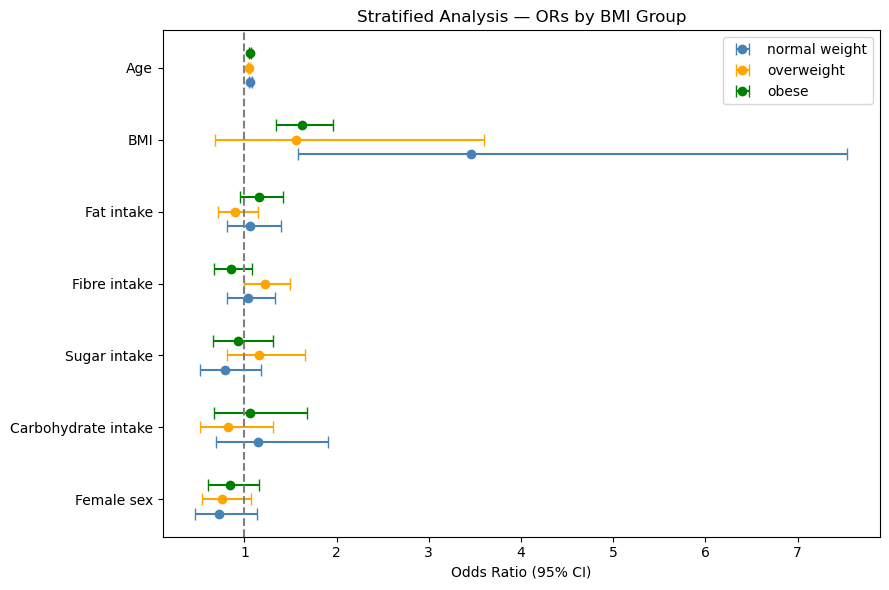

Saved: 03_stratified_forest_plot.png


In [9]:
y_pos   = range(len(results['normal weight'].index))
colors  = {'normal weight': 'steelblue', 'overweight': 'orange', 'obese': 'green'}
offsets = {'normal weight': -0.2, 'overweight': 0.0, 'obese': 0.2}

fig, ax = plt.subplots(figsize=(9, 6))
for group in ['normal weight', 'overweight', 'obese']:
    df_g = results[group]
    y = [pos + offsets[group] for pos in y_pos]
    ax.errorbar(
        x=df_g['OR'], y=y,
        xerr=[df_g['OR'] - df_g['CI_low'], df_g['CI_high'] - df_g['OR']],
        fmt='o', color=colors[group], capsize=4, label=group
    )

ax.axvline(x=1, linestyle='--', color='grey')
ax.set_yticks(y_pos)
ax.set_yticklabels(results['normal weight'].index)
ax.set_xlabel('Odds Ratio (95% CI)')
ax.set_title('Stratified Analysis — ORs by BMI Group')
ax.legend()
plt.tight_layout()
plt.savefig('/Users/larascofano/Documents/Obsidian Vault/career/Portfolio 2/figures/03_stratified_forest_plot.png', dpi=150)
plt.show()
print("Saved: 03_stratified_forest_plot.png")

## Step 8: Save summary table

In [10]:
# Rebuild or_df from logit_model for the summary (it was sorted/renamed above)
OR = np.exp(logit_model.params)
CI = np.exp(logit_model.conf_int())
or_df_final = pd.DataFrame({'OR': OR, 'CI_low': CI[0], 'CI_high': CI[1]}).drop('Intercept')
or_df_final = or_df_final.rename(index=rename_map)

# p-values with matching index
linear_p = model.pvalues.drop('Intercept').rename(index=rename_map).rename('linear_p')
logit_p  = logit_model.pvalues.drop('Intercept').rename(index=rename_map).rename('or_p')

# coef_df already has readable index from Step 4
coef_df_final = pd.DataFrame({
    'coef':    model.params.drop('Intercept').rename(index=rename_map),
    'ci_low':  model.conf_int()[0].drop('Intercept').rename(index=rename_map),
    'ci_high': model.conf_int()[1].drop('Intercept').rename(index=rename_map),
    'linear_p': linear_p
})

or_df_final['or_p'] = logit_p

summary = coef_df_final.merge(or_df_final, left_index=True, right_index=True)
summary.to_csv('../data/03_model_summary.csv', index=True)

print("Summary table:")
print(summary.round(3).to_string())
print()
print("Saved: ../data/03_model_summary.csv")

Summary table:
                      coef  ci_low  ci_high  linear_p     OR  CI_low  CI_high   or_p
Female sex          -0.127  -0.217   -0.038     0.005  0.776   0.633    0.952  0.015
Carbohydrate intake -0.112  -0.233    0.008     0.067  0.974   0.741    1.281  0.852
Sugar intake         0.043  -0.049    0.136     0.357  0.968   0.786    1.193  0.760
Fibre intake         0.062   0.004    0.120     0.035  1.042   0.915    1.187  0.531
Fat intake          -0.004  -0.063    0.054     0.882  1.046   0.917    1.194  0.502
BMI                  0.244   0.202    0.287     0.000  1.805   1.628    2.002  0.000
Age                  0.018   0.015    0.020     0.000  1.059   1.053    1.066  0.000

Saved: ../data/03_model_summary.csv


---
## Key Findings

**Linear regression (R² = 0.147):**
- BMI (+0.244 per SD, p<0.001) and age (+0.018 per year, p<0.001) are the dominant predictors of HbA1c
- No dietary variable shows a significant positive association after adjustment
- Female sex is associated with 0.13% lower HbA1c (p=0.005)

**Logistic regression:**
- Each 1 SD increase in BMI → ~3× higher odds of prediabetes/diabetes
- Dietary variables: ORs close to 1.0, CIs wide, none significant after adjustment

**Stratified analysis:**
- Within each BMI stratum, dietary ORs remain near 1.0
- Confirms: the dietary null finding is not simply masked by BMI confounding

**Interpretation:** In a cross-sectional population sample, a single dietary recall snapshot is a poor predictor of chronic glycaemic state. Body composition (BMI) captures accumulated metabolic burden that dietary recall cannot.
